In [1]:
from google.colab import userdata
import os
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install kagglehub -q
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print(path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
/kaggle/input/creditcardfraud


In [2]:
import pandas as pd

df = pd.read_csv(path + "/creditcard.csv")
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [4]:
fraud_pct = df['Class'].value_counts(normalize=True) * 100
print(fraud_pct)

df.groupby('Class')['Amount'].describe()

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


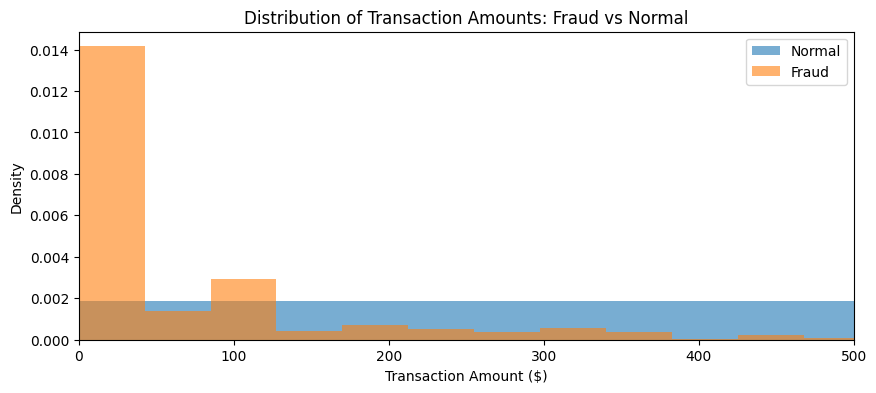

In [5]:
import matplotlib.pyplot as plt

fraud = df[df['Class'] == 1]['Amount']
normal = df[df['Class'] == 0]['Amount']

plt.figure(figsize=(10,4))
plt.hist(normal, bins=50, alpha=0.6, label='Normal', density=True)
plt.hist(fraud, bins=50, alpha=0.6, label='Fraud', density=True)
plt.xlim(0, 500)
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Density')
plt.title('Distribution of Transaction Amounts: Fraud vs Normal')
plt.legend()
plt.show()

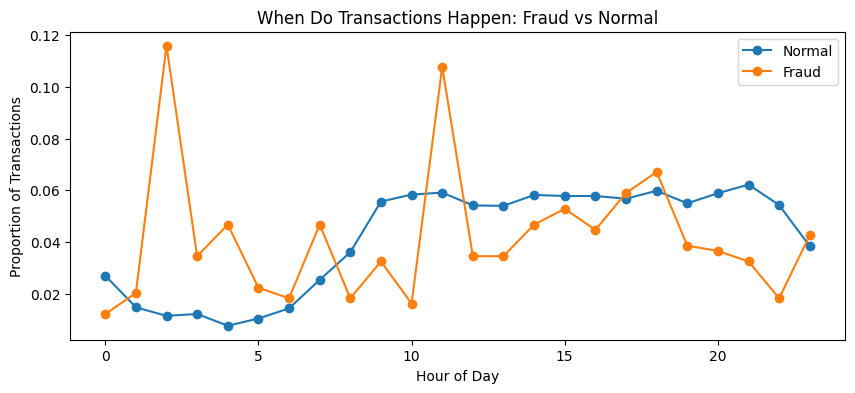

In [6]:
df['Hour'] = (df['Time'] // 3600) % 24

fraud_by_hour = df[df['Class']==1]['Hour'].value_counts().sort_index()
normal_by_hour = df[df['Class']==0]['Hour'].value_counts(normalize=True).sort_index()
fraud_by_hour_pct = df[df['Class']==1]['Hour'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(10,4))
plt.plot(normal_by_hour.index, normal_by_hour.values, label='Normal', marker='o')
plt.plot(fraud_by_hour_pct.index, fraud_by_hour_pct.values, label='Fraud', marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Proportion of Transactions')
plt.title('When Do Transactions Happen: Fraud vs Normal')
plt.legend()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Fraud cases in training:", y_train.sum())
print("Fraud cases in test:", y_test.sum())

Training set: (227845, 31)
Test set: (56962, 31)
Fraud cases in training: 394
Fraud cases in test: 98


In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model trained cleanly!")

Model trained cleanly!


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56851    13]
 [   35    63]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[56861     3]
 [   19    79]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.81      0.88        98

    accuracy                           1.00     56962
   macro avg       0.98      0.90      0.94     56962
weighted avg       1.00      1.00      1.00     56962



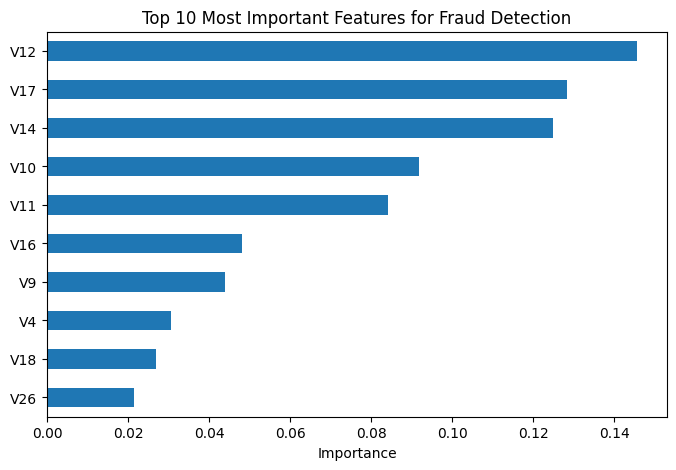

In [12]:
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features for Fraud Detection')
plt.show()

In [13]:
import numpy as np

y_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.1)
for t in thresholds:
    preds = (y_probs >= t).astype(int)
    tp = ((preds == 1) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    fn = ((preds == 0) & (y_test == 1)).sum()
    precision = tp / (tp + fp) if (tp+fp) > 0 else 0
    recall = tp / (tp + fn) if (tp+fn) > 0 else 0
    print(f"Threshold {t:.1f} | Precision: {precision:.2f} | Recall: {recall:.2f} | Caught: {tp}/98 | False alarms: {fp}")

Threshold 0.1 | Precision: 0.70 | Recall: 0.88 | Caught: 86/98 | False alarms: 37
Threshold 0.2 | Precision: 0.79 | Recall: 0.88 | Caught: 86/98 | False alarms: 23
Threshold 0.3 | Precision: 0.88 | Recall: 0.86 | Caught: 84/98 | False alarms: 12
Threshold 0.4 | Precision: 0.92 | Recall: 0.86 | Caught: 84/98 | False alarms: 7
Threshold 0.5 | Precision: 0.96 | Recall: 0.82 | Caught: 80/98 | False alarms: 3
Threshold 0.6 | Precision: 0.97 | Recall: 0.74 | Caught: 73/98 | False alarms: 2
Threshold 0.7 | Precision: 0.97 | Recall: 0.69 | Caught: 68/98 | False alarms: 2
Threshold 0.8 | Precision: 0.97 | Recall: 0.64 | Caught: 63/98 | False alarms: 2


In [14]:
final_preds = (y_probs >= 0.4).astype(int)

print("=== FINAL MODEL PERFORMANCE (Threshold = 0.4) ===")
print(confusion_matrix(y_test, final_preds))
print(classification_report(y_test, final_preds))

=== FINAL MODEL PERFORMANCE (Threshold = 0.4) ===
[[56857     7]
 [   14    84]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.86      0.89        98

    accuracy                           1.00     56962
   macro avg       0.96      0.93      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [15]:
!pip install xgboost -q
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

[[56851    13]
 [   20    78]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

